# 📊 SINITT G2 — Notebook de Análisis v2
**Equipo G2 · Ruta de Data y Analítica · EAFIT · Grow Data**

| Capa | ¿Qué hace? | ¿Para qué? |
|---|---|---|
| **EDA** | Medidas de tendencia central y dispersión por base de datos | Entender los datos antes de concluir |
| **KPIs** | Cálculo de los 4 indicadores del dashboard | Responder preguntas de movilidad |

> **Responsable:** Juan Zúñiga Giraldo (DA)  
> **Recibe datos de:** Supabase — tablas cargadas por María Alejandra Valencia (DE)  
> **Datos certificados por:** Carol Licet Ospina (DQA)  
> **Entrega resultados a:** Luz Duque (BI Developer)

---
**⚠️ ANTES DE EJECUTAR:**
1. Guarda `SUPABASE_URL` y `SUPABASE_KEY` en Secretos de Colab (ícono de llave)
2. Activa el toggle **'Notebook access'** para cada secreto
3. Ejecuta de arriba a abajo — no saltes secciones

## 0. Instalación de dependencias
Ejecutar solo una vez al abrir el notebook en Colab.

In [ ]:
!pip install supabase --quiet
print('✅ Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.8 MB/s eta 0:00:00
✅ Dependencias instaladas


## 1. Importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from supabase import create_client
from google.colab import userdata
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
COLORES = ['#2563EB', '#0891B2', '#16A34A', '#D97706', '#7C3AED', '#DC2626']

print(f'✅ Librerías listas — pandas {pd.__version__} | numpy {np.__version__}')

✅ Librerías listas — pandas 2.2.2 | numpy 2.0.2


## 2. Zona de Configuración
> Las credenciales se leen desde Secretos de Colab — nunca las escribas directamente aquí.
> Si necesitas cambiar parámetros analíticos, hazlo en esta sección únicamente.
> Todo el notebook usa estas variables — un solo cambio se propaga a todo.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CREDENCIALES SUPABASE
# ══════════════════════════════════════════════════════════════════════
SUPABASE_URL = userdata.get('SUPABASE_URL')
SUPABASE_KEY = userdata.get('SUPABASE_KEY')

print(f'URL : {SUPABASE_URL[:35]}...' if SUPABASE_URL else '❌ SUPABASE_URL no encontrada')
print(f'KEY : {SUPABASE_KEY[:20]}...' if SUPABASE_KEY else '❌ SUPABASE_KEY no encontrada')

# ══════════════════════════════════════════════════════════════════════
# NOMBRES DE TABLAS EN SUPABASE
# ══════════════════════════════════════════════════════════════════════
TABLA_BD2 = 'rutas'
TABLA_BD3 = 'paradas'
TABLA_BD5 = 'velocidad_trafico'
TABLA_BD6 = 'intensidad'
TABLA_BD7 = 'incidentes_viales'

# ══════════════════════════════════════════════════════════════════════
# BD5 — velocidad_trafico (2018–2020)
# Nota: 2017 fue eliminado de Supabase para liberar espacio
# ══════════════════════════════════════════════════════════════════════
BD5_CORREDOR  = 'nombre_corredor'
BD5_VELOCIDAD = 'velocidad_km_h'
BD5_HORA      = 'hora'
BD5_FECHA     = 'fecha'

# ══════════════════════════════════════════════════════════════════════
# BD6 — intensidad (jul–ago 2020)
# ══════════════════════════════════════════════════════════════════════
BD6_CORREDOR   = 'corredor'
BD6_VELOCIDAD  = 'velocidad_km_h'
BD6_INTENSIDAD = 'intensidad'
BD6_CAT1       = 'categoria_1'
BD6_CAT2       = 'categoria_2'
BD6_CAT3       = 'categoria_3'
BD6_HORA       = 'hora'
BD6_LAT        = 'latitud'
BD6_LON        = 'longitud'

# ══════════════════════════════════════════════════════════════════════
# BD7 — incidentes_viales (2014–2020)
# ══════════════════════════════════════════════════════════════════════
BD7_FECHA    = 'fecha_accidentes'
BD7_CORREDOR = 'comuna'
BD7_GRAVEDAD = 'gravedad_accidente'
BD7_LAT      = 'latitud'
BD7_LON      = 'longitud'

# ══════════════════════════════════════════════════════════════════════
# BD2 — rutas (248 rutas)
# Nota: longitud está en METROS — se convierte a km en KPI 4
# ══════════════════════════════════════════════════════════════════════
BD2_ID_RUTA  = 'id_ruta'
BD2_LONGITUD = 'longitud'   # en metros

# ══════════════════════════════════════════════════════════════════════
# BD3 — paradas (10,043 paradas)
# ══════════════════════════════════════════════════════════════════════
BD3_ID_RUTA = 'id_ruta'

# ══════════════════════════════════════════════════════════════════════
# PARÁMETROS ANALÍTICOS
# Nota: BD5 solo tiene horas 6-20 (sensores activos en horario diurno)
# Horas valle = horas con mayor velocidad promedio según EDA
# Horas pico  = horas con menor velocidad promedio según EDA
# ══════════════════════════════════════════════════════════════════════
HORAS_PICO            = [15, 16, 17, 18]   # menor velocidad promedio
HORAS_VALLE           = [6, 20]             # mayor velocidad promedio
PERCENTIL_FLUJO_LIBRE = 85
UMBRAL_IVH_CRITICO    = 3000               # veh/h

print('\n✅ Configuración lista')
print(f'   Horas pico : {HORAS_PICO}')
print(f'   Horas valle: {HORAS_VALLE}')

URL : https://dutltpmxhiqltrfidvkq.supaba...
KEY : eyJhbGciOiJIUzI1NiIs...

✅ Configuración lista
   Horas pico : [15, 16, 17, 18]
   Horas valle: [6, 20]


## 3. Carga de Datos desde Supabase

In [ ]:
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print('✅ Cliente Supabase creado correctamente')

✅ Cliente Supabase creado correctamente


In [ ]:
def cargar_tabla(nombre_tabla, nombre_legible):
    """
    Lee una tabla completa de Supabase con paginación automática.
    Supabase limita 1,000 filas por consulta — itera hasta traer todo.
    """
    try:
        todos = []
        offset = 0
        limite = 1000
        while True:
            respuesta = (
                supabase.table(nombre_tabla)
                .select('*')
                .range(offset, offset + limite - 1)
                .execute()
            )
            batch = respuesta.data
            if not batch:
                break
            todos.extend(batch)
            offset += limite
            if len(batch) < limite:
                break
        df = pd.DataFrame(todos)
        print(f'✅ {nombre_legible}: {df.shape[0]:,} registros | {df.shape[1]} columnas')
        return df
    except Exception as e:
        print(f'❌ {nombre_legible}: error → {e}')
        return None

print('── Cargando tablas desde Supabase ─────────────────────────────────')
df_bd2 = cargar_tabla(TABLA_BD2, 'BD2 Rutas de Transporte (248 rutas)')
df_bd3 = cargar_tabla(TABLA_BD3, 'BD3 Paradas de Transporte (10,043 paradas)')
df_bd5 = cargar_tabla(TABLA_BD5, 'BD5 Velocidad y Tiempo de Viaje (2018-2020)')
df_bd6 = cargar_tabla(TABLA_BD6, 'BD6 Velocidad e Intensidad Vehicular (jul-ago 2020)')
df_bd7 = cargar_tabla(TABLA_BD7, 'BD7 Incidentes Viales Medellín (270,693 registros)')
print('────────────────────────────────────────────────────────────────────')

── Cargando tablas desde Supabase ─────────────────────────────────
✅ BD2 Rutas de Transporte (248 rutas): 248 registros | 9 columnas
✅ BD3 Paradas de Transporte (10,043 paradas): 10,043 registros | 14 columnas
✅ BD5 Velocidad y Tiempo de Viaje (2018-2020): 556,683 registros | 20 columnas
✅ BD6 Velocidad e Intensidad Vehicular (jul-ago 2020): 431,490 registros | 23 columnas
✅ BD7 Incidentes Viales Medellín (270,693 registros): 270,693 registros | 13 columnas
────────────────────────────────────────────────────────────────────


### 3.1 Verificar columnas reales
> Ejecuta esta celda para confirmar que los nombres coinciden con los de la Sección 2.

In [ ]:
def mostrar_columnas(df, nombre):
    if df is not None:
        print(f'\n📋 {nombre}')
        print(f'   Columnas: {list(df.columns)}')
        print(f'   Muestra :')
        print(df.head(2).to_string())

mostrar_columnas(df_bd2, 'BD2 — rutas')
mostrar_columnas(df_bd3, 'BD3 — paradas')
mostrar_columnas(df_bd5, 'BD5 — velocidad_trafico')
mostrar_columnas(df_bd6, 'BD6 — intensidad')
mostrar_columnas(df_bd7, 'BD7 — incidentes_viales')


📋 BD2 — rutas
   Columnas: ['id_ruta', 'nombre', 'longitud', 'codigo', 'sistema', 'tipo', 'empresa', 'recorrido', 'fecha']
   Muestra :
   id_ruta                                  nombre      longitud codigo sistema            tipo                       empresa       recorrido                fecha
0    90111                12 DE OCTUBRE - CALLE 90  19982.069944    263      2B  DIRECTA CENTRO  TRANSPORTE MEDELLÍN CASTILLA  ORIGEN_DESTINO  2018-08-01T00:00:00
1    90113  12 DE OCTUBRE - ESTACIÓN TRICENTENARIO   8842.359411   263I      2B       INTEGRADA  TRANSPORTE MEDELLÍN CASTILLA  ORIGEN_DESTINO  2024-08-27T00:00:00

📋 BD3 — paradas
   Columnas: ['id_paradero', 'id_parada', 'id_ruta', 'nro_parada', 'nombre_ruta', 'codigo_ruta', 'tipo_ruta', 'empresa', 'longitud', 'latitud', 'recorrido', 'sistema_ruta', 'tipo_parada', 'objectid']
   Muestra :
   id_paradero  id_parada  id_ruta  nro_parada               nombre_ruta codigo_ruta       tipo_ruta                     empresa   longitud   la

### 3.2 Conversión de tipos de dato

In [ ]:
if df_bd5 is not None:
    df_bd5[BD5_FECHA]     = pd.to_datetime(df_bd5[BD5_FECHA], errors='coerce')
    df_bd5[BD5_HORA]      = pd.to_numeric(df_bd5[BD5_HORA], errors='coerce')
    df_bd5[BD5_VELOCIDAD] = pd.to_numeric(df_bd5[BD5_VELOCIDAD], errors='coerce')
    print(f'✅ BD5: tipos convertidos | nulos velocidad: {df_bd5[BD5_VELOCIDAD].isna().sum()}')

if df_bd6 is not None:
    df_bd6[BD6_HORA]       = pd.to_numeric(df_bd6[BD6_HORA], errors='coerce')
    df_bd6[BD6_VELOCIDAD]  = pd.to_numeric(df_bd6[BD6_VELOCIDAD], errors='coerce')
    df_bd6[BD6_INTENSIDAD] = pd.to_numeric(df_bd6[BD6_INTENSIDAD], errors='coerce')
    print(f'✅ BD6: tipos convertidos | nulos velocidad: {df_bd6[BD6_VELOCIDAD].isna().sum()}')

if df_bd7 is not None:
    df_bd7[BD7_FECHA] = pd.to_datetime(df_bd7[BD7_FECHA], errors='coerce')
    df_bd7['anio']    = df_bd7[BD7_FECHA].dt.year
    df_bd7['mes_num'] = df_bd7[BD7_FECHA].dt.month
    print(f'✅ BD7: fecha convertida | nulos: {df_bd7[BD7_FECHA].isna().sum()}')

if df_bd2 is not None:
    df_bd2[BD2_LONGITUD] = pd.to_numeric(df_bd2[BD2_LONGITUD], errors='coerce')
    print(f'✅ BD2: longitud convertida (valores en metros)')

print('\n✅ Conversiones listas — datos listos para EDA')

✅ BD5: tipos convertidos | nulos velocidad: 0
✅ BD6: tipos convertidos | nulos velocidad: 0
✅ BD7: fecha convertida | nulos: 0
✅ BD2: longitud convertida (valores en metros)

✅ Conversiones listas — datos listos para EDA


## 4. Análisis Exploratorio (EDA)
**Medidas de tendencia central** → dónde se agrupa el fenómeno (media, mediana, moda)

**Medidas de dispersión** → qué tan volátil es (desv. estándar, IQR, percentiles)

El **percentil 85** en horas valle es la velocidad de flujo libre del **KPI 1**.

In [ ]:
def eda_numerica(serie, nombre_col, nombre_bd):
    s = serie.dropna()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    lim_inf = s.quantile(0.25) - 1.5 * iqr
    lim_sup = s.quantile(0.75) + 1.5 * iqr
    outliers = ((s < lim_inf) | (s > lim_sup)).sum()
    stats = {
        'registros_validos': len(s),
        'nulos'            : serie.isna().sum(),
        'media'            : s.mean(),
        'mediana'          : s.median(),
        'moda'             : s.mode().iloc[0] if len(s.mode()) > 0 else None,
        'desv_estandar'    : s.std(),
        'minimo'           : s.min(),
        'p25'              : s.quantile(0.25),
        'p75'              : s.quantile(0.75),
        'p85'              : s.quantile(0.85),
        'maximo'           : s.max(),
        'iqr'              : iqr,
        'outliers_iqr'     : int(outliers),
    }
    etiquetas = {
        'registros_validos': 'Registros válidos',
        'nulos'            : 'Valores nulos',
        'media'            : 'Media              ← tendencia central',
        'mediana'          : 'Mediana            ← tendencia central',
        'moda'             : 'Moda               ← tendencia central',
        'desv_estandar'    : 'Desv. Estándar     ← dispersión',
        'minimo'           : 'Mínimo',
        'p25'              : 'Percentil 25',
        'p75'              : 'Percentil 75',
        'p85'              : 'Percentil 85       ← INSUMO KPI 1 (flujo libre)',
        'maximo'           : 'Máximo',
        'iqr'              : 'IQR                ← dispersión',
        'outliers_iqr'     : 'Outliers estimados (método IQR)',
    }
    print(f'\n📊 {nombre_bd} | Columna: {nombre_col}')
    print('─' * 62)
    for k, label in etiquetas.items():
        v = stats[k]
        if isinstance(v, float):
            print(f'  {label:<44}: {v:,.2f}')
        else:
            print(f'  {label:<44}: {v}')
    return stats

print('✅ Función EDA lista')

✅ Función EDA lista


### 4.1 EDA — BD5: velocidad_trafico (2018–2020)
**Nota:** La BD solo contiene horas 6–20 (sensores activos en horario diurno).
Horas valle = 6 y 20 (mayor velocidad). Horas pico = 15–18 (menor velocidad).

In [ ]:
if df_bd5 is not None:
    stats_bd5 = eda_numerica(df_bd5[BD5_VELOCIDAD], BD5_VELOCIDAD, 'BD5 velocidad_trafico')

    print('\n📋 Estadísticos por corredor vial (BD5):')
    resumen_corredor = (
        df_bd5.groupby(BD5_CORREDOR)[BD5_VELOCIDAD]
        .agg(
            Media='mean',
            Mediana='median',
            Desv_Std='std',
            P85_flujo_libre=lambda x: x.quantile(0.85)
        )
        .round(2)
        .sort_values('Media')
    )
    print(resumen_corredor.to_string())
else:
    print('⚠️  BD5 no cargada')


📊 BD5 velocidad_trafico | Columna: velocidad_km_h
──────────────────────────────────────────────────────────────
  Registros válidos                           : 556683
  Valores nulos                               : 0
  Media              ← tendencia central      : 29.86
  Mediana            ← tendencia central      : 26.90
  Moda               ← tendencia central      : 20.00
  Desv. Estándar     ← dispersión             : 13.50
  Mínimo                                      : 3.00
  Percentil 25                                : 20.00
  Percentil 75                                : 38.00
  Percentil 85       ← INSUMO KPI 1 (flujo libre): 46.00
  Máximo                                      : 77.90
  IQR                ← dispersión             : 18.00
  Outliers estimados (método IQR)             : 5405

📋 Estadísticos por corredor vial (BD5):
                     Media  Mediana  Desv_Std  P85_flujo_libre
nombre_corredor                                               
AVENIDA ORIENTAL   

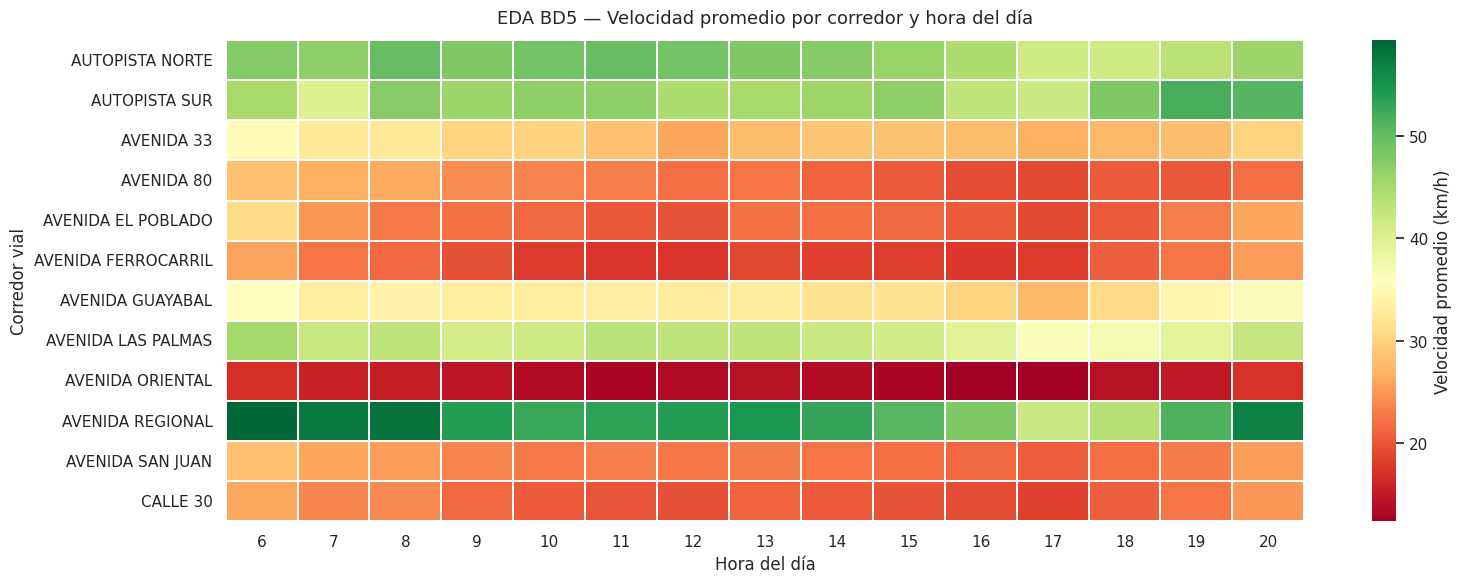

✅ eda_bd5_heatmap_velocidad.png guardado


In [ ]:
if df_bd5 is not None:
    pivot = df_bd5.pivot_table(
        values=BD5_VELOCIDAD,
        index=BD5_CORREDOR,
        columns=BD5_HORA,
        aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(pivot, cmap='RdYlGn', annot=False, linewidths=0.3,
                cbar_kws={'label': 'Velocidad promedio (km/h)'}, ax=ax)
    ax.set_title('EDA BD5 — Velocidad promedio por corredor y hora del día',
                 fontsize=13, pad=12)
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Corredor vial')
    plt.tight_layout()
    plt.savefig('eda_bd5_heatmap_velocidad.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ eda_bd5_heatmap_velocidad.png guardado')

### 4.2 EDA — BD6: intensidad (jul–ago 2020)
Tiene la desagregación por tipo de vehículo que necesita el **KPI 3**.
**Nota:** Datos de pandemia — intensidad más baja de lo normal.

In [ ]:
if df_bd6 is not None:
    stats_bd6_vel = eda_numerica(df_bd6[BD6_VELOCIDAD], BD6_VELOCIDAD, 'BD6 intensidad')
    if BD6_INTENSIDAD in df_bd6.columns:
        stats_bd6_int = eda_numerica(df_bd6[BD6_INTENSIDAD], BD6_INTENSIDAD, 'BD6 Intensidad total')
    cats = [c for c in [BD6_CAT1, BD6_CAT2, BD6_CAT3] if c in df_bd6.columns]
    if cats:
        print('\n📋 Intensidad promedio por tipo de vehículo (BD6):')
        labels = {BD6_CAT1:'Livianos', BD6_CAT2:'Motos/Ciclos', BD6_CAT3:'Pesados'}
        for c in cats:
            print(f'   {labels.get(c,c):<15}: {df_bd6[c].mean():,.1f} veh/h promedio')
else:
    print('⚠️  BD6 no cargada')


📊 BD6 intensidad | Columna: velocidad_km_h
──────────────────────────────────────────────────────────────
  Registros válidos                           : 431490
  Valores nulos                               : 0
  Media              ← tendencia central      : 28.50
  Mediana            ← tendencia central      : 26.00
  Moda               ← tendencia central      : 27
  Desv. Estándar     ← dispersión             : 15.91
  Mínimo                                      : 0
  Percentil 25                                : 17.00
  Percentil 75                                : 37.00
  Percentil 85       ← INSUMO KPI 1 (flujo libre): 44.00
  Máximo                                      : 205
  IQR                ← dispersión             : 20.00
  Outliers estimados (método IQR)             : 9169

📊 BD6 Intensidad total | Columna: intensidad
──────────────────────────────────────────────────────────────
  Registros válidos                           : 431490
  Valores nulos                      

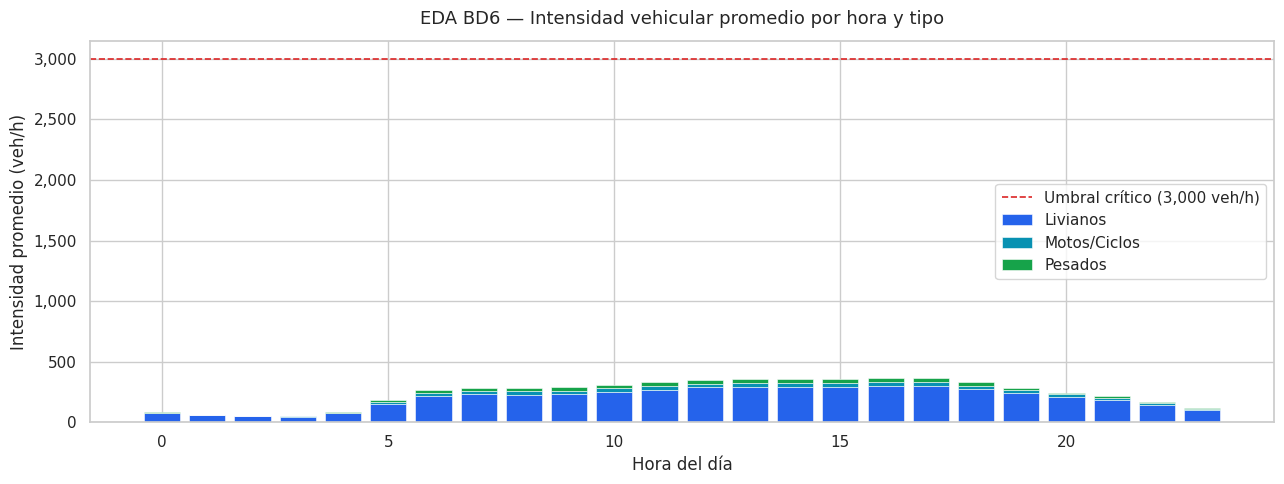

✅ eda_bd6_intensidad_horaria.png guardado


In [ ]:
if df_bd6 is not None:
    cats = [c for c in [BD6_CAT1, BD6_CAT2, BD6_CAT3] if c in df_bd6.columns]
    if cats:
        por_hora = df_bd6.groupby(BD6_HORA)[cats].mean()
        labels_leg = ['Livianos', 'Motos/Ciclos', 'Pesados'][:len(cats)]
        fig, ax = plt.subplots(figsize=(13, 5))
        bottom = np.zeros(len(por_hora))
        for i, (cat, label) in enumerate(zip(cats, labels_leg)):
            ax.bar(por_hora.index, por_hora[cat], bottom=bottom,
                   label=label, color=COLORES[i], edgecolor='white', linewidth=0.4)
            bottom += por_hora[cat].values
        ax.axhline(UMBRAL_IVH_CRITICO, color='#DC2626', linestyle='--',
                   linewidth=1.2, label=f'Umbral crítico ({UMBRAL_IVH_CRITICO:,} veh/h)')
        ax.set_title('EDA BD6 — Intensidad vehicular promedio por hora y tipo',
                     fontsize=13, pad=12)
        ax.set_xlabel('Hora del día')
        ax.set_ylabel('Intensidad promedio (veh/h)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.legend()
        plt.tight_layout()
        plt.savefig('eda_bd6_intensidad_horaria.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅ eda_bd6_intensidad_horaria.png guardado')

### 4.3 EDA — BD7: incidentes_viales (2014–2020)
270,693 registros. Base del **KPI 2**.
**Nota:** 12,794 registros sin comuna asignada (4.7%) — limitación documentada por DQA.

In [ ]:
if df_bd7 is not None:
    if BD7_GRAVEDAD in df_bd7.columns:
        print('📋 Distribución por gravedad (BD7):')
        dist = df_bd7[BD7_GRAVEDAD].value_counts()
        for grav, cant in dist.items():
            pct = cant / len(df_bd7) * 100
            print(f'   {str(grav):<30}: {cant:>8,} ({pct:.1f}%)')
    if 'anio' in df_bd7.columns:
        print('\n📋 Incidentes por año:')
        por_anio = df_bd7['anio'].value_counts().sort_index()
        for anio, cant in por_anio.items():
            print(f'   {anio}: {cant:,}')
    if BD7_CORREDOR in df_bd7.columns:
        print('\n📋 Top 10 comunas con más incidentes:')
        top_comunas = df_bd7[BD7_CORREDOR].value_counts().head(10)
        for comuna, cant in top_comunas.items():
            print(f'   {str(comuna):<25}: {cant:,}')
else:
    print('⚠️  BD7 no cargada')

📋 Distribución por gravedad (BD7):
   CON HERIDOS                   :  150,066 (55.4%)
   SOLO DAÑOS                    :  119,196 (44.0%)
   CON MUERTOS                   :    1,431 (0.5%)

📋 Incidentes por año:
   2014: 22,391
   2015: 46,179
   2016: 47,074
   2017: 46,188
   2018: 43,352
   2019: 45,785
   2020: 19,724

📋 Top 10 comunas con más incidentes:
   LA CANDELARIA            : 52,175
   LAURELES ESTADIO         : 27,060
   CASTILLA                 : 24,935
   EL POBLADO               : 21,759
   GUAYABAL                 : 18,540
   ROBLEDO                  : 16,509
   ARANJUEZ                 : 14,380
   BELÉN                    : 14,117
   NONE                     : 12,794
   BUENOS AIRES             : 9,884


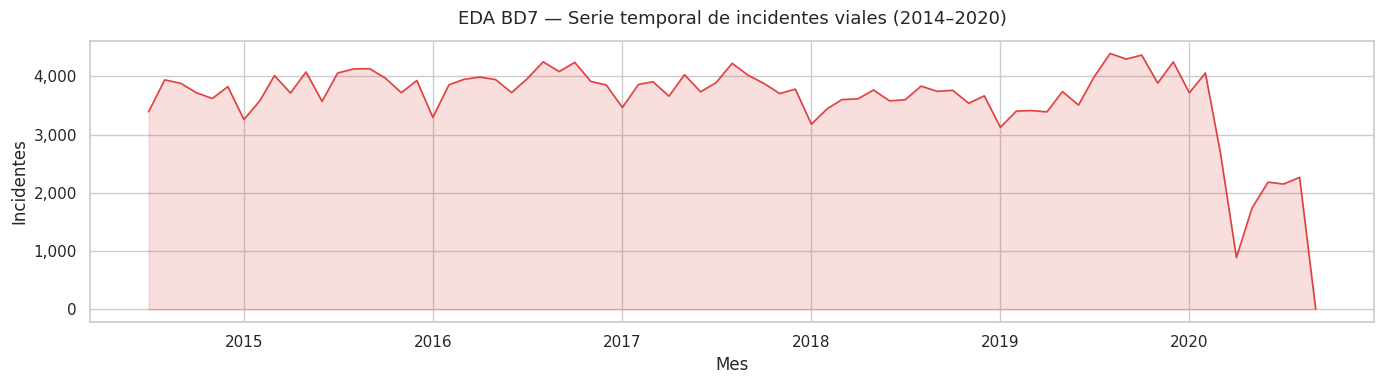

✅ eda_bd7_serie_temporal.png guardado


In [ ]:
if df_bd7 is not None:
    serie_mensual = (
        df_bd7.groupby(df_bd7[BD7_FECHA].dt.to_period('M'))
        .size().reset_index(name='incidentes')
    )
    serie_mensual[BD7_FECHA] = serie_mensual[BD7_FECHA].dt.to_timestamp()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(serie_mensual[BD7_FECHA], serie_mensual['incidentes'],
            color='#DC2626', linewidth=1.2, alpha=0.85)
    ax.fill_between(serie_mensual[BD7_FECHA], serie_mensual['incidentes'],
                    alpha=0.15, color='#DC2626')
    ax.set_title('EDA BD7 — Serie temporal de incidentes viales (2014–2020)',
                 fontsize=13, pad=12)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Incidentes')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('eda_bd7_serie_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ eda_bd7_serie_temporal.png guardado')

📊 Distribución de accidentes por hora del día (BD7):
 hora  incidentes  pct
    0       13099  4.8
    1       11033  4.1
    2        9116  3.4
    3        6441  2.4
    4        3760  1.4
    5        2823  1.0
    6        3835  1.4
    7        3476  1.3
    8        3265  1.2
    9        4109  1.5
   10        8748  3.2
   11       16098  5.9
   12       17416  6.4
   13       13940  5.1
   14       13062  4.8
   15       14028  5.2
   16       14913  5.5
   17       16785  6.2
   18       15156  5.6
   19       14996  5.5
   20       15391  5.7
   21       16169  6.0
   22       18024  6.7
   23       15010  5.5

🎯 Hora con MÁS accidentes : 22:00
   Top 3 horas peligrosas  :
   22:00 → 18,024 accidentes (6.7%)
   12:00 → 17,416 accidentes (6.4%)
   17:00 → 16,785 accidentes (6.2%)


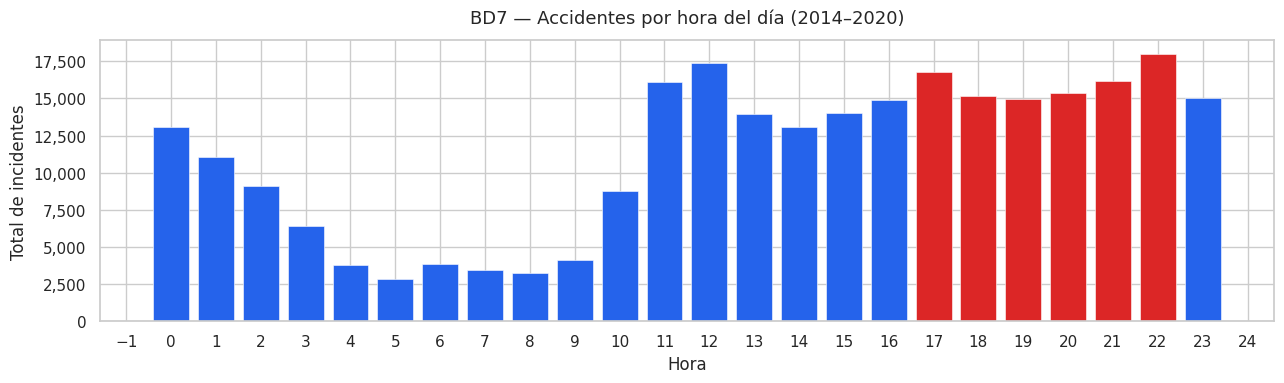

✅ verificacion_hora_pico_bd7.png guardado


In [ ]:
# ══════════════════════════════════════════════════════
# VERIFICACIÓN: distribución de accidentes por hora
# ══════════════════════════════════════════════════════
if df_bd7 is not None:
    df_bd7['hora_accidente'] = pd.to_datetime(
        df_bd7[BD7_FECHA], errors='coerce'
    ).dt.hour

    hora_dist = (
        df_bd7['hora_accidente']
        .value_counts()
        .sort_index()
        .reset_index()
    )
    hora_dist.columns = ['hora', 'incidentes']
    hora_dist['pct'] = (hora_dist['incidentes'] / hora_dist['incidentes'].sum() * 100).round(1)

    print('📊 Distribución de accidentes por hora del día (BD7):')
    print(hora_dist.to_string(index=False))

    hora_pico_real = hora_dist.loc[hora_dist['incidentes'].idxmax(), 'hora']
    top3 = hora_dist.nlargest(3, 'incidentes')

    print(f'\n🎯 Hora con MÁS accidentes : {int(hora_pico_real):02d}:00')
    print(f'   Top 3 horas peligrosas  :')
    for _, row in top3.iterrows():
        print(f'   {int(row.hora):02d}:00 → {int(row.incidentes):,} accidentes ({row.pct}%)')

    fig, ax = plt.subplots(figsize=(13, 4))
    colores_hora = ['#DC2626' if h in range(17, 23) else '#2563EB'
                    for h in hora_dist['hora']]
    ax.bar(hora_dist['hora'], hora_dist['incidentes'],
           color=colores_hora, edgecolor='white', linewidth=0.4)
    ax.set_title('BD7 — Accidentes por hora del día (2014–2020)',
                 fontsize=13, pad=12)
    ax.set_xlabel('Hora')
    ax.set_ylabel('Total de incidentes')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('verificacion_hora_pico_bd7.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ verificacion_hora_pico_bd7.png guardado')

### 4.4 EDA — BD2 + BD3: rutas y paradas
248 rutas y 10,043 paradas. Join por `id_ruta` para el **KPI 4**.
**Nota:** longitud en BD2 está en metros — se convierte a km en el cálculo del KPI.

In [ ]:
if df_bd2 is not None and df_bd3 is not None:
    paradas_x_ruta = df_bd3.groupby(BD3_ID_RUTA).size().reset_index(name='num_paradas')
    print(f'📋 Rutas con paradas registradas: {paradas_x_ruta.shape[0]}')
    eda_numerica(paradas_x_ruta['num_paradas'], 'paradas por ruta', 'BD3')
    print()
    # Mostrar longitud en km para interpretación
    longitud_km = df_bd2[BD2_LONGITUD] / 1000
    eda_numerica(longitud_km, 'longitud_km (convertida)', 'BD2')
else:
    print('⚠️  BD2 o BD3 no cargadas')

📋 Rutas con paradas registradas: 247

📊 BD3 | Columna: paradas por ruta
──────────────────────────────────────────────────────────────
  Registros válidos                           : 247
  Valores nulos                               : 0
  Media              ← tendencia central      : 40.66
  Mediana            ← tendencia central      : 38.00
  Moda               ← tendencia central      : 28
  Desv. Estándar     ← dispersión             : 19.47
  Mínimo                                      : 1
  Percentil 25                                : 26.00
  Percentil 75                                : 49.50
  Percentil 85       ← INSUMO KPI 1 (flujo libre): 58.00
  Máximo                                      : 103
  IQR                ← dispersión             : 23.50
  Outliers estimados (método IQR)             : 11


📊 BD2 | Columna: longitud_km (convertida)
──────────────────────────────────────────────────────────────
  Registros válidos                           : 248
  Valores nulos    

## 5. KPIs del Dashboard
---

### KPI 1 — Índice de Congestión Vial (ICV)
**Fórmula:** `ICV (%) = ((Vel. flujo libre − Vel. observada) / Vel. flujo libre) × 100`

**Vel. flujo libre** = percentil 85 en horas valle (6h y 20h) por corredor.

| ICV | Estado |
|---|---|
| < 20% | Flujo libre 🟢 |
| 20–50% | Congestión moderada 🟡 |
| > 50% | Congestión crítica 🔴 |

**Fuente:** BD5 — velocidad_trafico (2018–2020)

In [ ]:
def calcular_icv(df, col_corredor, col_velocidad, col_hora,
                 horas_valle, horas_pico, percentil=85):
    """
    KPI 1 — Índice de Congestión Vial por corredor.
    Vel. flujo libre = percentil 85 en horas valle (horas de mayor velocidad).
    Vel. observada   = promedio en horas pico (horas de menor velocidad).
    """
    flujo_libre = (
        df[df[col_hora].isin(horas_valle)]
        .groupby(col_corredor)[col_velocidad]
        .quantile(percentil / 100)
        .reset_index()
        .rename(columns={col_velocidad: 'vel_flujo_libre'})
    )
    vel_pico = (
        df[df[col_hora].isin(horas_pico)]
        .groupby(col_corredor)[col_velocidad]
        .mean()
        .reset_index()
        .rename(columns={col_velocidad: 'vel_observada'})
    )
    resultado = flujo_libre.merge(vel_pico, on=col_corredor, how='inner')
    resultado['ICV'] = (
        (resultado['vel_flujo_libre'] - resultado['vel_observada'])
        / resultado['vel_flujo_libre'] * 100
    ).clip(lower=0).round(1)
    resultado['estado'] = pd.cut(
        resultado['ICV'],
        bins=[-1, 20, 50, 100],
        labels=['Flujo libre 🟢', 'Congestión moderada 🟡', 'Congestión crítica 🔴']
    )
    return resultado.sort_values('ICV', ascending=False)

print('✅ Función KPI 1 lista')

✅ Función KPI 1 lista


In [ ]:
if df_bd5 is not None:
    kpi1 = calcular_icv(
        df_bd5, BD5_CORREDOR, BD5_VELOCIDAD, BD5_HORA,
        HORAS_VALLE, HORAS_PICO, PERCENTIL_FLUJO_LIBRE
    )
    print('📊 KPI 1 — ICV por corredor vial:')
    print(kpi1.to_string(index=False))
    print(f'\n🎯 ICV General Medellín     : {kpi1["ICV"].mean():.1f}%')
    if len(kpi1) > 0:
        print(f'   Corredor más congestionado: {kpi1.iloc[0][BD5_CORREDOR]} ({kpi1.iloc[0]["ICV"]:.1f}%)')
        print(f'   Corredor con mejor flujo  : {kpi1.iloc[-1][BD5_CORREDOR]} ({kpi1.iloc[-1]["ICV"]:.1f}%)')
    n_crit = (kpi1['estado'] == 'Congestión crítica 🔴').sum()
    print(f'   Corredores estado crítico : {n_crit} de {len(kpi1)}')
else:
    print('⚠️  BD5 no disponible')

📊 KPI 1 — ICV por corredor vial:
    nombre_corredor  vel_flujo_libre  vel_observada  ICV                estado
   AVENIDA ORIENTAL           22.000      12.961428 41.1 Congestión moderada 🟡
 AVENIDA EL POBLADO           34.000      20.323048 40.2 Congestión moderada 🟡
         AVENIDA 80           32.200      19.794525 38.5 Congestión moderada 🟡
AVENIDA FERROCARRIL           30.200      18.633970 38.3 Congestión moderada 🟡
           CALLE 30           29.000      19.622490 32.3 Congestión moderada 🟡
   AVENIDA REGIONAL           66.700      46.049742 31.0 Congestión moderada 🟡
   AVENIDA SAN JUAN           30.800      21.494807 30.2 Congestión moderada 🟡
         AVENIDA 33           38.000      27.602371 27.4 Congestión moderada 🟡
   AVENIDA GUAYABAL           40.900      29.909813 26.9 Congestión moderada 🟡
      AUTOPISTA SUR           60.875      45.022920 26.0 Congestión moderada 🟡
    AUTOPISTA NORTE           57.100      43.475899 23.9 Congestión moderada 🟡
 AVENIDA LAS PALMAS

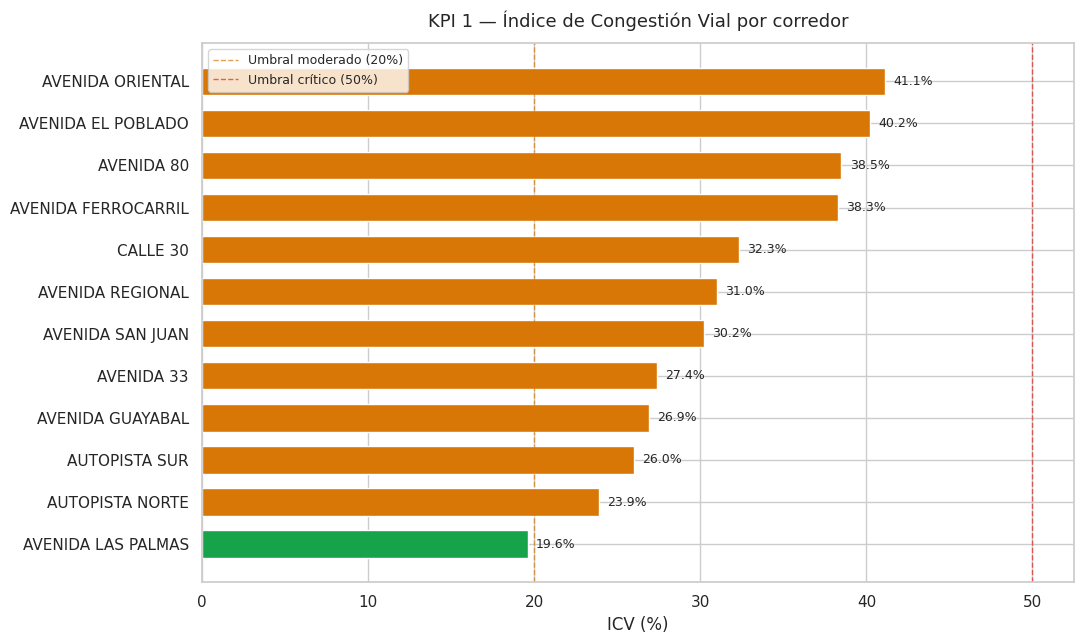

✅ kpi1_icv_corredores.png guardado


In [ ]:
if df_bd5 is not None and 'kpi1' in dir() and len(kpi1) > 0:
    color_map = {
        'Flujo libre 🟢'         : '#16A34A',
        'Congestión moderada 🟡' : '#D97706',
        'Congestión crítica 🔴'  : '#DC2626'
    }
    # .astype(str) necesario para evitar error con columnas categóricas
    colores_barra = kpi1['estado'].astype(str).map(color_map).fillna('#64748B')
    fig, ax = plt.subplots(figsize=(11, max(4, len(kpi1) * 0.55)))
    bars = ax.barh(kpi1[BD5_CORREDOR], kpi1['ICV'],
                   color=colores_barra, edgecolor='white', height=0.65)
    ax.axvline(20, color='#D97706', linestyle='--', linewidth=1, alpha=0.7,
               label='Umbral moderado (20%)')
    ax.axvline(50, color='#DC2626', linestyle='--', linewidth=1, alpha=0.7,
               label='Umbral crítico (50%)')
    for bar, val in zip(bars, kpi1['ICV']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title('KPI 1 — Índice de Congestión Vial por corredor', fontsize=13, pad=12)
    ax.set_xlabel('ICV (%)')
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('kpi1_icv_corredores.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ kpi1_icv_corredores.png guardado')

### KPI 2 — Accidentalidad Vial por Comuna
**Fuente:** BD7 — incidentes_viales (270,693 registros, 2014–2020)

**Nota:** 12,794 registros (4.7%) sin comuna asignada — documentado en reporte DQA.

In [ ]:
def calcular_accidentalidad(df, col_fecha, col_corredor, col_gravedad):
    por_corredor_gravedad = (
        df.groupby([col_corredor, col_gravedad])
        .size().reset_index(name='incidentes')
        .sort_values('incidentes', ascending=False)
    )
    top10 = (
        df.groupby(col_corredor).size()
        .reset_index(name='total')
        .sort_values('total', ascending=False)
        .head(10)
    )
    serie = (
        df.groupby(df[col_fecha].dt.to_period('M')).size()
        .reset_index(name='incidentes')
    )
    serie[col_fecha] = serie[col_fecha].dt.to_timestamp()
    return por_corredor_gravedad, top10, serie

print('✅ Función KPI 2 lista')

✅ Función KPI 2 lista


📊 KPI 2 — Top 10 comunas con más incidentes:
          comuna  total
   LA CANDELARIA  52175
LAURELES ESTADIO  27060
        CASTILLA  24935
      EL POBLADO  21759
        GUAYABAL  18540
         ROBLEDO  16509
        ARANJUEZ  14380
           BELÉN  14117
            NONE  12794
    BUENOS AIRES   9884


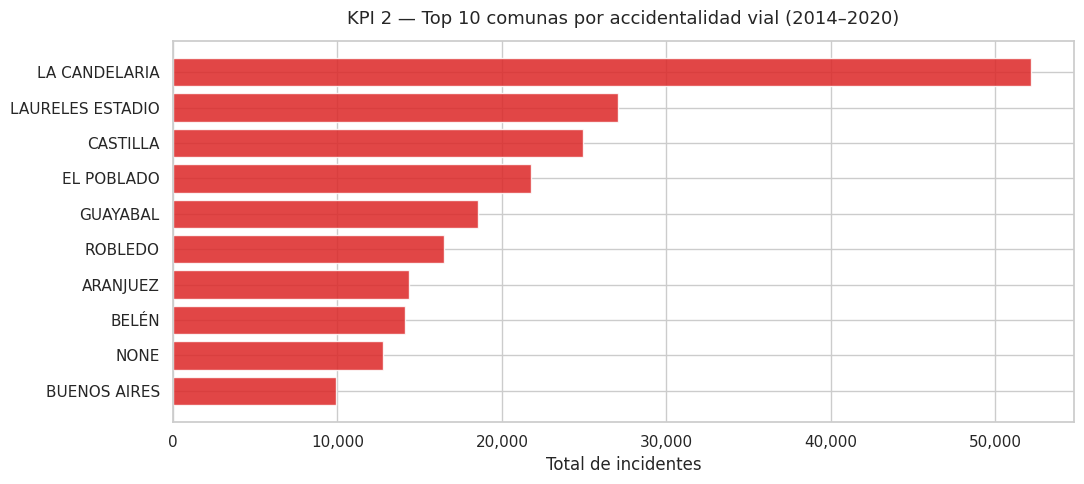

✅ kpi2_accidentalidad_top10.png guardado


In [ ]:
if df_bd7 is not None:
    kpi2_detalle, kpi2_top10, kpi2_serie = calcular_accidentalidad(
        df_bd7, BD7_FECHA, BD7_CORREDOR, BD7_GRAVEDAD
    )
    print('📊 KPI 2 — Top 10 comunas con más incidentes:')
    print(kpi2_top10.to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(kpi2_top10[BD7_CORREDOR].astype(str), kpi2_top10['total'],
            color='#DC2626', alpha=0.85, edgecolor='white')
    ax.set_title('KPI 2 — Top 10 comunas por accidentalidad vial (2014–2020)',
                 fontsize=13, pad=12)
    ax.set_xlabel('Total de incidentes')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('kpi2_accidentalidad_top10.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ kpi2_accidentalidad_top10.png guardado')
else:
    print('⚠️  BD7 no disponible')

### KPI 3 — Intensidad Vehicular Horaria (IVH)
**Fórmula:** `IVH = Promedio de intensidad por corredor y hora` (desagregado por tipo)

**Nota:** Se usa promedio (no suma) para evitar acumulación de múltiples días.

**Umbral:** IVH > 3,000 veh/h → corredor al límite de capacidad

**Fuente:** BD6 — intensidad (jul–ago 2020, datos de pandemia)

In [ ]:
def calcular_intensidad_horaria(df, col_corredor, col_hora, col_c1, col_c2, col_c3):
    """
    KPI 3 — Intensidad vehicular horaria por corredor.
    Usa PROMEDIO por corredor+hora para evitar acumulación de múltiples días.
    """
    cats = [c for c in [col_c1, col_c2, col_c3] if c in df.columns]
    detalle = (
        df.groupby([col_corredor, col_hora])[cats]
        .mean()   # promedio, no suma
        .reset_index()
    )
    detalle['IVH_total'] = detalle[cats].sum(axis=1)
    resumen = (
        detalle.groupby(col_corredor)['IVH_total']
        .agg(IVH_promedio='mean', IVH_maximo='max')
        .round(0).sort_values('IVH_maximo', ascending=False)
        .reset_index()
    )
    resumen['estado'] = resumen['IVH_maximo'].apply(
        lambda x: 'Al límite 🔴' if x > UMBRAL_IVH_CRITICO else 'Normal 🟢'
    )
    return detalle, resumen

print('✅ Función KPI 3 lista')

✅ Función KPI 3 lista


📊 KPI 3 — Intensidad vehicular máxima por corredor:
                        corredor  IVH_promedio  IVH_maximo   estado
                   AUTOPISTA SUR         590.0       901.0 Normal 🟢
                 AUTOPISTA NORTE         632.0       891.0 Normal 🟢
                AVENIDA REGIONAL         499.0       806.0 Normal 🟢
               REGIONAL PARALELA         471.0       703.0 Normal 🟢
                  LOMA EL TESORO         341.0       605.0 Normal 🟢
                        CALLE 71         362.0       600.0 Normal 🟢
              AVENIDA LAS PALMAS         307.0       594.0 Normal 🟢
                        CALLE 73         263.0       473.0 Normal 🟢
            CALLE 57 - ARGENTINA         276.0       452.0 Normal 🟢
                        COLOMBIA         283.0       428.0 Normal 🟢
                  TRANSVERSAL 78         287.0       427.0 Normal 🟢
        CALLE 9 SUR - LOS BALSOS         215.0       413.0 Normal 🟢
             AVENIDA FERROCARRIL         268.0       409.0 Norma

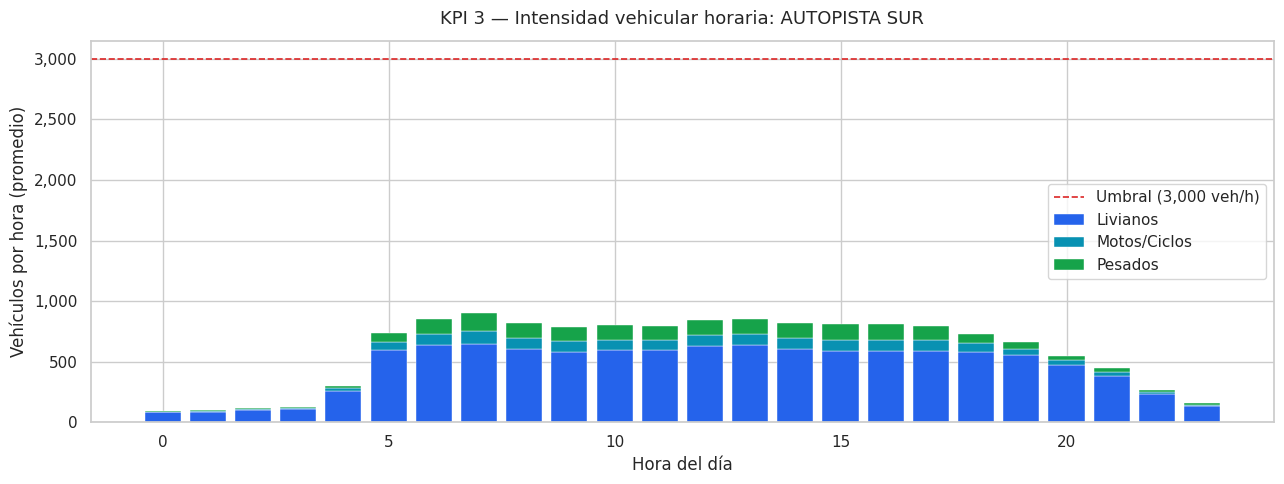

✅ kpi3_intensidad_horaria.png guardado


In [ ]:
if df_bd6 is not None:
    kpi3_detalle, kpi3_resumen = calcular_intensidad_horaria(
        df_bd6, BD6_CORREDOR, BD6_HORA, BD6_CAT1, BD6_CAT2, BD6_CAT3
    )
    print('📊 KPI 3 — Intensidad vehicular máxima por corredor:')
    print(kpi3_resumen.to_string(index=False))

    corredor_max = kpi3_resumen.iloc[0][BD6_CORREDOR]
    datos_max = kpi3_detalle[kpi3_detalle[BD6_CORREDOR] == corredor_max].sort_values(BD6_HORA)
    cats = [c for c in [BD6_CAT1, BD6_CAT2, BD6_CAT3] if c in datos_max.columns]
    labels_leg = ['Livianos', 'Motos/Ciclos', 'Pesados'][:len(cats)]

    if cats:
        fig, ax = plt.subplots(figsize=(13, 5))
        bottom = np.zeros(len(datos_max))
        for i, (cat, label) in enumerate(zip(cats, labels_leg)):
            ax.bar(datos_max[BD6_HORA], datos_max[cat], bottom=bottom,
                   label=label, color=COLORES[i], edgecolor='white', linewidth=0.3)
            bottom += datos_max[cat].values
        ax.axhline(UMBRAL_IVH_CRITICO, color='#DC2626', linestyle='--',
                   linewidth=1.2, label=f'Umbral ({UMBRAL_IVH_CRITICO:,} veh/h)')
        ax.set_title(f'KPI 3 — Intensidad vehicular horaria: {corredor_max}',
                     fontsize=13, pad=12)
        ax.set_xlabel('Hora del día')
        ax.set_ylabel('Vehículos por hora (promedio)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax.legend()
        plt.tight_layout()
        plt.savefig('kpi3_intensidad_horaria.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('✅ kpi3_intensidad_horaria.png guardado')
else:
    print('⚠️  BD6 no disponible')

### KPI 4 — Eficiencia de la Red de Transporte Público
**Fórmula:** `Densidad (paradas/km) = Número de paradas ÷ Longitud de la ruta (km)`

**Nota:** Longitud en BD2 está en metros → se divide por 1,000 para convertir a km.

| Densidad | Cobertura |
|---|---|
| < 2 paradas/km | Baja 🔴 |
| 2–7 paradas/km | Adecuada 🟢 |
| > 7 paradas/km | Sobredotación 🟡 |

**Fuentes:** BD2 — rutas + BD3 — paradas (join por `id_ruta`)

In [ ]:
def calcular_densidad_red(df_rutas, df_paradas, col_id_r, col_long, col_id_p):
    """
    KPI 4 — Densidad de paradas por km.
    Importante: col_long está en METROS — se convierte a km dividiendo por 1,000.
    """
    paradas_x_ruta = (
        df_paradas.groupby(col_id_p).size()
        .reset_index(name='num_paradas')
    )
    resultado = (
        df_rutas[[col_id_r, col_long]]
        .merge(paradas_x_ruta, left_on=col_id_r, right_on=col_id_p, how='inner')
    )
    resultado[col_long] = pd.to_numeric(resultado[col_long], errors='coerce')
    # División por 1,000 para convertir metros a kilómetros
    resultado['densidad_paradas_km'] = (
        resultado['num_paradas'] / (resultado[col_long] / 1000)
    ).round(2)
    resultado['cobertura'] = pd.cut(
        resultado['densidad_paradas_km'],
        bins=[-1, 2, 7, float('inf')],
        labels=['Baja 🔴', 'Adecuada 🟢', 'Sobredotación 🟡']
    )
    return resultado.sort_values('densidad_paradas_km')

print('✅ Función KPI 4 lista')

✅ Función KPI 4 lista


📊 KPI 4 — Resumen densidad de red:

📊 KPI 4 | Columna: densidad_paradas_km
──────────────────────────────────────────────────────────────
  Registros válidos                           : 243
  Valores nulos                               : 0
  Media              ← tendencia central      : 2.49
  Mediana            ← tendencia central      : 2.35
  Moda               ← tendencia central      : 2.17
  Desv. Estándar     ← dispersión             : 0.99
  Mínimo                                      : 0.20
  Percentil 25                                : 1.97
  Percentil 75                                : 2.90
  Percentil 85       ← INSUMO KPI 1 (flujo libre): 3.31
  Máximo                                      : 7.26
  IQR                ← dispersión             : 0.93
  Outliers estimados (método IQR)             : 25

Distribución por categoría:
   Adecuada 🟢: 177 rutas (72.8%)
   Baja 🔴: 65 rutas (26.7%)
   Sobredotación 🟡: 1 rutas (0.4%)


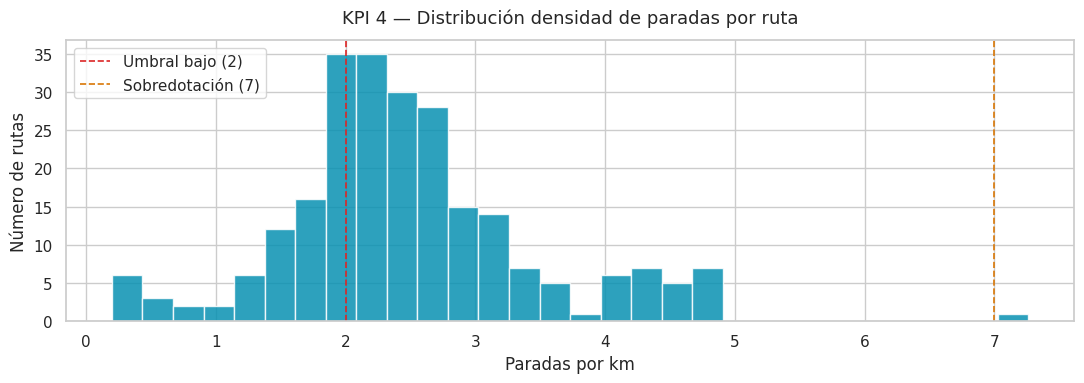

✅ kpi4_densidad_red.png guardado


In [ ]:
if df_bd2 is not None and df_bd3 is not None:
    kpi4 = calcular_densidad_red(df_bd2, df_bd3, BD2_ID_RUTA, BD2_LONGITUD, BD3_ID_RUTA)
    print('📊 KPI 4 — Resumen densidad de red:')
    eda_numerica(kpi4['densidad_paradas_km'], 'densidad_paradas_km', 'KPI 4')
    print('\nDistribución por categoría:')
    for cat, cnt in kpi4['cobertura'].value_counts().items():
        print(f'   {cat}: {cnt} rutas ({cnt/len(kpi4)*100:.1f}%)')

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.hist(kpi4['densidad_paradas_km'].dropna(), bins=30,
            color='#0891B2', edgecolor='white', alpha=0.85)
    ax.axvline(2, color='#DC2626', linestyle='--', linewidth=1.2, label='Umbral bajo (2)')
    ax.axvline(7, color='#D97706', linestyle='--', linewidth=1.2, label='Sobredotación (7)')
    ax.set_title('KPI 4 — Distribución densidad de paradas por ruta', fontsize=13, pad=12)
    ax.set_xlabel('Paradas por km')
    ax.set_ylabel('Número de rutas')
    ax.legend()
    plt.tight_layout()
    plt.savefig('kpi4_densidad_red.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ kpi4_densidad_red.png guardado')
else:
    print('⚠️  BD2 o BD3 no disponibles')

## 6. Resumen Ejecutivo
Consolidación de los 4 KPIs para entregar a Luz (BI Developer).

In [ ]:
print('=' * 62)
print('SINITT G2 — RESUMEN EJECUTIVO DE KPIs')
print('Equipo G2 · Grow Data · EAFIT · Medellín')
print('=' * 62)

if 'kpi1' in dir() and len(kpi1) > 0:
    print(f'\nKPI 1 — Índice de Congestión Vial')
    print(f'  ICV general Medellín        : {kpi1["ICV"].mean():.1f}%')
    print(f'  Corredor más congestionado  : {kpi1.iloc[0][BD5_CORREDOR]} ({kpi1.iloc[0]["ICV"]:.1f}%)')
    print(f'  Corredor con mejor flujo    : {kpi1.iloc[-1][BD5_CORREDOR]} ({kpi1.iloc[-1]["ICV"]:.1f}%)')
    n_crit = (kpi1['estado'] == 'Congestión crítica 🔴').sum()
    print(f'  Corredores estado crítico   : {n_crit} de {len(kpi1)}')

if 'kpi2_top10' in dir():
    print(f'\nKPI 2 — Accidentalidad Vial')
    print(f'  Total incidentes 2014-2020  : {len(df_bd7):,}')
    print(f'  Comuna más peligrosa        : {kpi2_top10.iloc[0][BD7_CORREDOR]} ({kpi2_top10.iloc[0]["total"]:,})')
    top3 = kpi2_top10.head(3)['total'].sum()
    print(f'  Top 3 comunas concentran    : {top3/len(df_bd7)*100:.1f}% de accidentes')

if 'kpi3_resumen' in dir():
    print(f'\nKPI 3 — Intensidad Vehicular Horaria')
    print(f'  Corredor más cargado        : {kpi3_resumen.iloc[0][BD6_CORREDOR]}')
    print(f'  IVH máximo                  : {kpi3_resumen.iloc[0]["IVH_maximo"]:,.0f} veh/h')
    print(f'  Corredores al límite        : {(kpi3_resumen["estado"]=="Al límite 🔴").sum()} de {len(kpi3_resumen)}')
    print(f'  Contexto                    : Datos de pandemia (jul-ago 2020)')

if 'kpi4' in dir():
    baja = (kpi4['cobertura'] == 'Baja 🔴').sum()
    adec = (kpi4['cobertura'] == 'Adecuada 🟢').sum()
    print(f'\nKPI 4 — Densidad de Red de Transporte')
    print(f'  Rutas analizadas            : {len(kpi4)}')
    print(f'  Densidad promedio           : {kpi4["densidad_paradas_km"].mean():.2f} paradas/km')
    print(f'  Rutas con cobertura baja    : {baja} ({baja/len(kpi4)*100:.1f}%)')
    print(f'  Rutas con cobertura adecuada: {adec} ({adec/len(kpi4)*100:.1f}%)')

print('\n' + '=' * 62)

SINITT G2 — RESUMEN EJECUTIVO DE KPIs
Equipo G2 · Grow Data · EAFIT · Medellín

KPI 1 — Índice de Congestión Vial
  ICV general Medellín        : 31.3%
  Corredor más congestionado  : AVENIDA ORIENTAL (41.1%)
  Corredor con mejor flujo    : AVENIDA LAS PALMAS (19.6%)
  Corredores estado crítico   : 0 de 12

KPI 2 — Accidentalidad Vial
  Total incidentes 2014-2020  : 270,693
  Comuna más peligrosa        : LA CANDELARIA (52,175)
  Top 3 comunas concentran    : 38.5% de accidentes

KPI 3 — Intensidad Vehicular Horaria
  Corredor más cargado        : AUTOPISTA SUR
  IVH máximo                  : 901 veh/h
  Corredores al límite        : 0 de 49
  Contexto                    : Datos de pandemia (jul-ago 2020)

KPI 4 — Densidad de Red de Transporte
  Rutas analizadas            : 243
  Densidad promedio           : 2.49 paradas/km
  Rutas con cobertura baja    : 65 (26.7%)
  Rutas con cobertura adecuada: 177 (72.8%)



## 7. Exportación de Resultados
Exporta los KPIs a CSV y los carga en Supabase.
Luz (BI Developer) conecta estas tablas directamente desde Lovable.

In [ ]:
os.makedirs('resultados_kpis', exist_ok=True)

exportados = []
if 'kpi1' in dir() and len(kpi1) > 0:
    kpi1.to_csv('resultados_kpis/kpi1_icv_corredores.csv', index=False)
    exportados.append('kpi1_icv_corredores.csv')

if 'kpi2_top10' in dir():
    kpi2_top10.to_csv('resultados_kpis/kpi2_top10_comunas.csv', index=False)
    kpi2_detalle.to_csv('resultados_kpis/kpi2_detalle_comuna_gravedad.csv', index=False)
    exportados.extend(['kpi2_top10_comunas.csv', 'kpi2_detalle_comuna_gravedad.csv'])

if 'kpi3_resumen' in dir():
    kpi3_resumen.to_csv('resultados_kpis/kpi3_intensidad_horaria.csv', index=False)
    exportados.append('kpi3_intensidad_horaria.csv')

if 'kpi4' in dir():
    kpi4.to_csv('resultados_kpis/kpi4_densidad_red.csv', index=False)
    exportados.append('kpi4_densidad_red.csv')

print('📁 Archivos exportados en resultados_kpis/:')
for f in exportados:
    print(f'   ✅ {f}')
print('\n→ Carpeta lista para entregar a Luz (BI Developer)')

📁 Archivos exportados en resultados_kpis/:
   ✅ kpi1_icv_corredores.csv
   ✅ kpi2_top10_comunas.csv
   ✅ kpi2_detalle_comuna_gravedad.csv
   ✅ kpi3_intensidad_horaria.csv
   ✅ kpi4_densidad_red.csv

→ Carpeta lista para entregar a Luz (BI Developer)


In [ ]:
def cargar_resultado_supabase(df, nombre_tabla, descripcion):
    """
    Carga un DataFrame de resultados en Supabase.
    Convierte categóricas a string y NaN a None para compatibilidad JSON.
    """
    try:
        df_export = df.copy()
        for col in df_export.select_dtypes(include='category').columns:
            df_export[col] = df_export[col].astype(str)
        registros = df_export.where(pd.notnull(df_export), None).to_dict('records')
        supabase.table(nombre_tabla).upsert(registros).execute()
        print(f'✅ {descripcion}: {len(registros):,} registros cargados en "{nombre_tabla}"')
    except Exception as e:
        print(f'❌ {descripcion}: error → {e}')

print('── Cargando resultados KPIs en Supabase ───────────────────────────')
if 'kpi1' in dir() and len(kpi1) > 0:
    cargar_resultado_supabase(kpi1, 'resultado_kpi1_icv', 'KPI 1 — ICV')
if 'kpi2_top10' in dir():
    cargar_resultado_supabase(kpi2_top10, 'resultado_kpi2_accidentalidad', 'KPI 2 — Accidentalidad')
if 'kpi3_resumen' in dir():
    cargar_resultado_supabase(kpi3_resumen, 'resultado_kpi3_intensidad', 'KPI 3 — Intensidad')
if 'kpi4' in dir():
    cargar_resultado_supabase(kpi4, 'resultado_kpi4_densidad', 'KPI 4 — Densidad de Red')
print('────────────────────────────────────────────────────────────────────')
print('✅ Resultados disponibles en Supabase para Lovable/Bolt')

── Cargando resultados KPIs en Supabase ───────────────────────────
✅ KPI 1 — ICV: 12 registros cargados en "resultado_kpi1_icv"
✅ KPI 2 — Accidentalidad: 10 registros cargados en "resultado_kpi2_accidentalidad"
✅ KPI 3 — Intensidad: 49 registros cargados en "resultado_kpi3_intensidad"
✅ KPI 4 — Densidad de Red: 243 registros cargados en "resultado_kpi4_densidad"
────────────────────────────────────────────────────────────────────
✅ Resultados disponibles en Supabase para Lovable/Bolt


---
**SINITT G2 · Grupo No. 2 · EAFIT · Entrega final: 20 mayo 2026 · Socialización: 12 junio 2026**

*Responsable del análisis: Juan Zúñiga Giraldo (DA)*  
*Datos cargados en Supabase por: María Alejandra Valencia (DE)*  
*Datos certificados por: Carol Licet Ospina (DQA)*  
*Resultados entregados a: Luz Duque (BI Developer)*  
*Empresa aliada: Grow Data*

**Observaciones técnicas documentadas:**
- BD5 solo contiene horas 6–20 (sensores activos en horario diurno)
- BD5: año 2017 eliminado de Supabase para liberar espacio (CSV original en GitHub)
- BD6: datos de pandemia (jul–ago 2020) — IVH más bajo de lo normal
- BD6: dos corredores con encoding corrupto (VÍA AL MAR, VÍA AL TÚNEL DE OCCIDENTE)
- BD6: 4 corredores con IVH = 0 (sensores sin datos en el período)
- BD7: 12,794 registros sin comuna asignada (4.7% del total)
- BD2: columna longitud en metros — convertida a km dividiendo por 1,000